In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from rich import print
import xarray as xr
import shutil

In [16]:
#import data
#imerg: Begin: 	2000-06-01T0000+00 End: 	2025-10-01T0000+00
#ERA5_LAND: 1950-01-01T01:00:00Z–2026-03-23T23:00:00Z
# CHIRPS: 1981-01-01T00:00:00Z–2026-02-28T00:00:00Z

# OPEN ET: 1999 - 2024
# Grace: 2002-04-01T00:00:00Z–2017-01-07T00:00:00Z
# MODIS: 2000 - 2025 
# precipitation = 
# evaporation =  
# temperature = 

# Calibration period
calibration_start_time = "2011-01-01T00:00:00Z"
calibration_end_time = "2011-12-31T00:00:00Z"

# Validation period
validation_start_time = "2011-01-01T00:00:00Z"
validation_end_time = "2011-12-31T00:00:00Z"

#growing_season_mask = #april to october 

SyntaxError: invalid syntax (2484961593.py, line 21)

**Precipitation Data:** Import/Mean and uncertainity 


In [4]:
### precipitation April until October every year
imerg = pd.read_csv("Moselle_NASA_GPM_L3_IMERG_MONTHLY_V07_precipitation_2000-06-01_2025-10-01.csv")
imerg['datetime'] = pd.to_datetime(imerg['system:index'], format='%Y%m%d%H%M%S')
hours_in_month = imerg['datetime'].dt.days_in_month * 24
imerg['precipitation_mm'] = imerg['precipitation'] * hours_in_month
imerg = imerg[imerg['datetime'].dt.month.between(4, 10)]

era5_precip = pd.read_csv("Moselle_ECMWF_ERA5_LAND_MONTHLY_AGGR_total_precipitation_sum_2000-06-01_2025-10-01.csv")
era5_precip['datetime'] = pd.to_datetime(era5_precip['system:index'], format='%Y%m')
era5_precip['monthly'] = era5_precip['total_precipitation_sum'] * 1000
era5_precip = era5_precip[era5_precip['datetime'].dt.month.between(4, 10)]

chirps = pd.read_csv("Moselle_CHIRPS_DAILY_precipitation_2000-06-01_2025-10-01.csv")
chirps['datetime'] = pd.to_datetime(chirps['system:index'], format='%Y%m%d')
chirps = chirps.groupby(chirps['datetime'].dt.to_period('M'))['precipitation'].sum().reset_index()
chirps.columns = ['datetime', 'monthly'] 
chirps['datetime'] = chirps['datetime'].dt.to_timestamp()  
chirps = chirps[chirps['datetime'].dt.month.between(4, 10)]

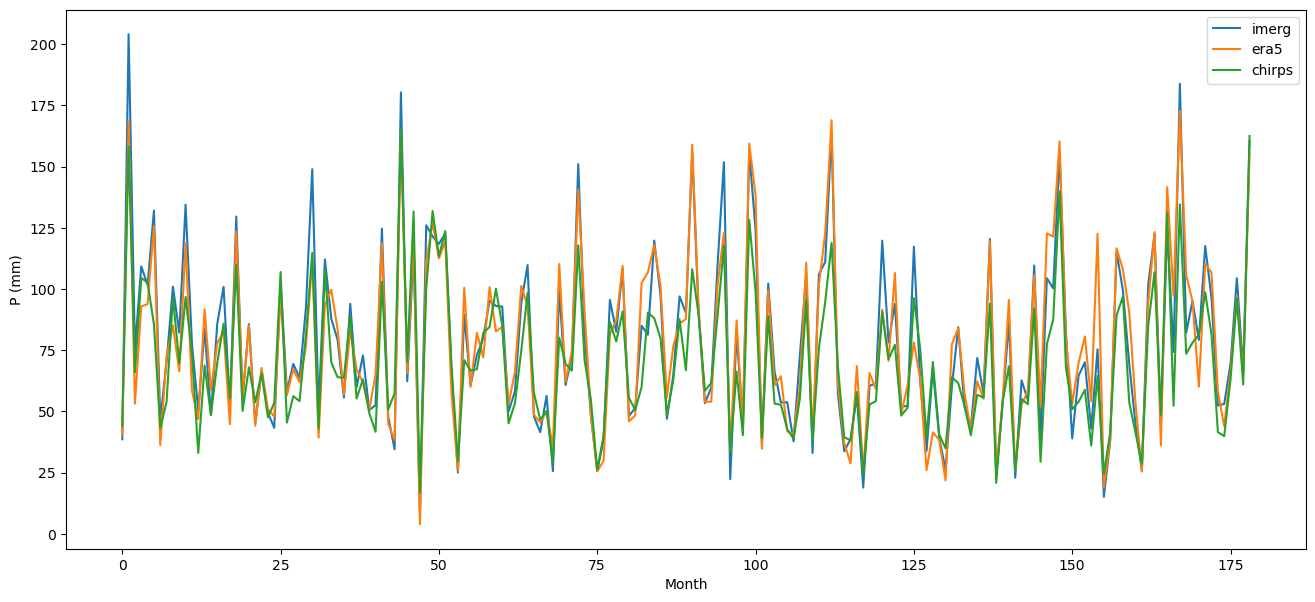

In [5]:
# Reading and plotting the monthly precipitation data
PObs1 = imerg['precipitation_mm'].to_numpy()
PObs2 = era5_precip['monthly'].to_numpy()
PObs3 = chirps['monthly'].to_numpy()

plt.figure(figsize=(16,7))
plt.plot(PObs1, label='imerg')
plt.plot(PObs2, label='era5')
plt.plot(PObs3, label='chirps')
plt.legend()
plt.xlabel('Month')
plt.ylabel('P (mm)');
plt.rcParams["font.size"] = 12

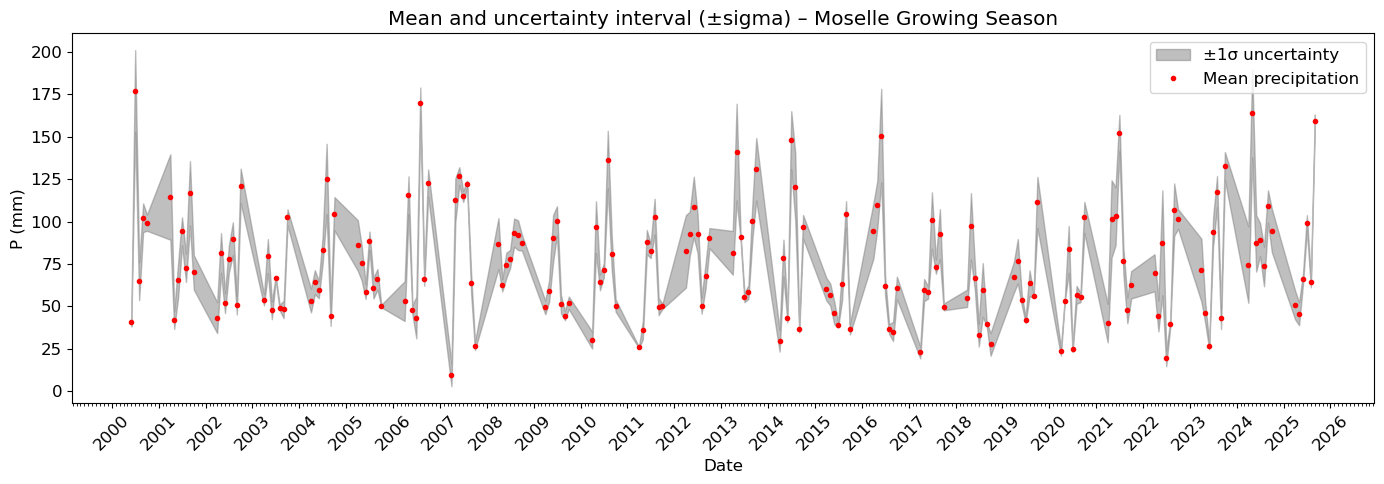

In [6]:
# Plot monthly mean and uncertainty interval (+-sigma) of precipitation
import matplotlib.dates as mdates

merged = pd.merge(imerg[['datetime', 'precipitation_mm']], 
                  era5_precip[['datetime', 'monthly']], 
                  on='datetime', how='inner')

merged = pd.merge(merged, 
                  chirps[['datetime','monthly']], 
                  on='datetime', how='inner',
                  suffixes=('_era5', '_chirps'))

merged['mP'] = (merged['precipitation_mm'] + 
                merged['monthly_era5'] + 
                merged['monthly_chirps']
             ) / 3

merged['vP'] = (
    np.square(merged['precipitation_mm'] - merged['mP']) +
    np.square(merged['monthly_era5'] - merged['mP']) +
    np.square(merged['monthly_chirps'] - merged['mP'])
) / (3 - 1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(merged['datetime'], 
                merged['mP'] - np.sqrt(merged['vP']), 
                merged['mP'] + np.sqrt(merged['vP']), 
                color='grey', alpha=0.5, label='±1σ uncertainty')

ax.plot(merged['datetime'], merged['mP'], 'r.', label='Mean precipitation')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.set_xlabel('Date')
ax.set_ylabel('P (mm)')
ax.set_title('Mean and uncertainty interval (±sigma) – Moselle Growing Season')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


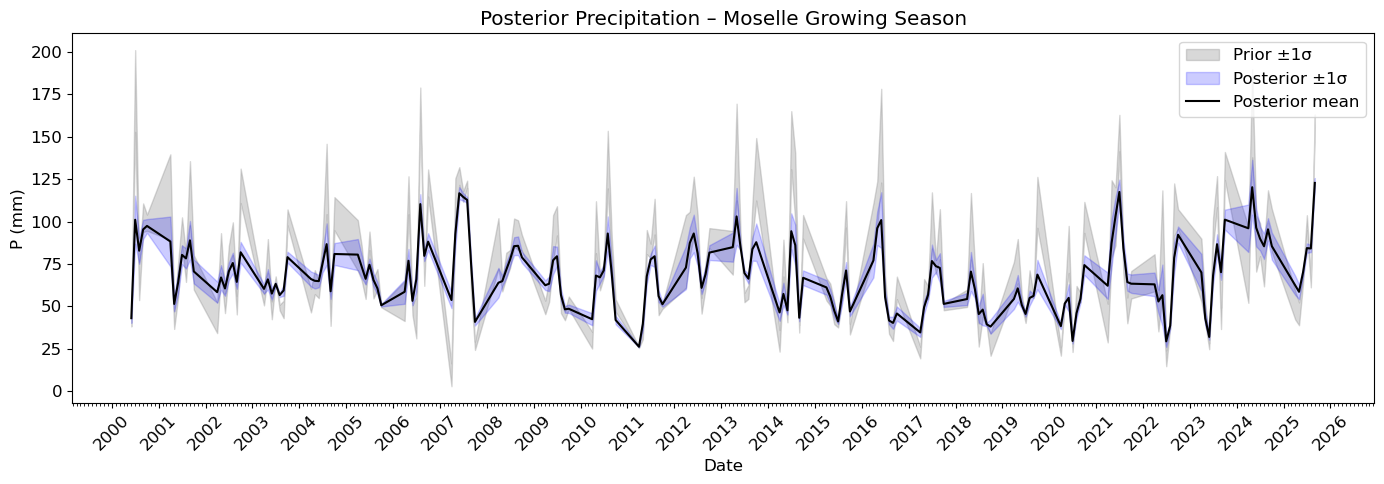

In [8]:
#Kalman Smoothing 
def gaussian_product(m1, v1, m2, v2):
    vPost = 1 / (1/v1 + 1/v2)
    mPost = vPost * (m1/v1 + m2/v2)
    return mPost, vPost

def smooth_precipitation(mP, vP):
    nt = len(mP)
    
    mFilt = np.zeros(nt)
    vFilt = np.zeros(nt)
    
    mFilt[0] = mP[0]
    vFilt[0] = vP[0]
    
    for t in range(1, nt):
        mPred = mFilt[t-1]
        vPred = vFilt[t-1] + vP[t]
        mFilt[t], vFilt[t] = gaussian_product(mPred, vPred, mP[t], vP[t])
    
    # Backward loop 
    mSmooth = np.zeros(nt)
    vSmooth = np.zeros(nt)
    mSmooth[-1] = mFilt[-1]
    vSmooth[-1] = vFilt[-1]
    
    for t in reversed(range(nt - 1)):
        mBack = mSmooth[t+1]
        vBack = vSmooth[t+1] + vP[t]
        mSmooth[t], vSmooth[t] = gaussian_product(mFilt[t], vFilt[t], mBack, vBack)
    
    return mSmooth, vSmooth

mP = merged['mP'].to_numpy()
vP = merged['vP'].to_numpy()

# Applying smoother
mPostP, vPostP = smooth_precipitation(mP, vP)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(merged['datetime'],
                mP - np.sqrt(vP),
                mP + np.sqrt(vP),
                color='grey', alpha=0.3, label='Prior ±1σ')

# Smoothed posterior
ax.fill_between(merged['datetime'],
                mPostP - np.sqrt(vPostP),
                mPostP + np.sqrt(vPostP),
                color='blue', alpha=0.2, label='Posterior ±1σ')

ax.plot(merged['datetime'], mPostP, 'k-', label='Posterior mean')
#ax.plot(merged['datetime'], merged['precipitation_mm'], 'r.', alpha=0.5, label='IMERG')
#ax.plot(merged['datetime'], merged['monthly_era5'], 'b.', alpha=0.5, label='ERA5')
#ax.plot(merged['datetime'], merged['monthly_chirps'], 'g.', alpha=0.5, label='CHIRPS')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.set_xlabel('Date')
ax.set_ylabel('P (mm)')
ax.set_title('Posterior Precipitation – Moselle Growing Season')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Evaporation Data**: Import/Mean and Uncertainty


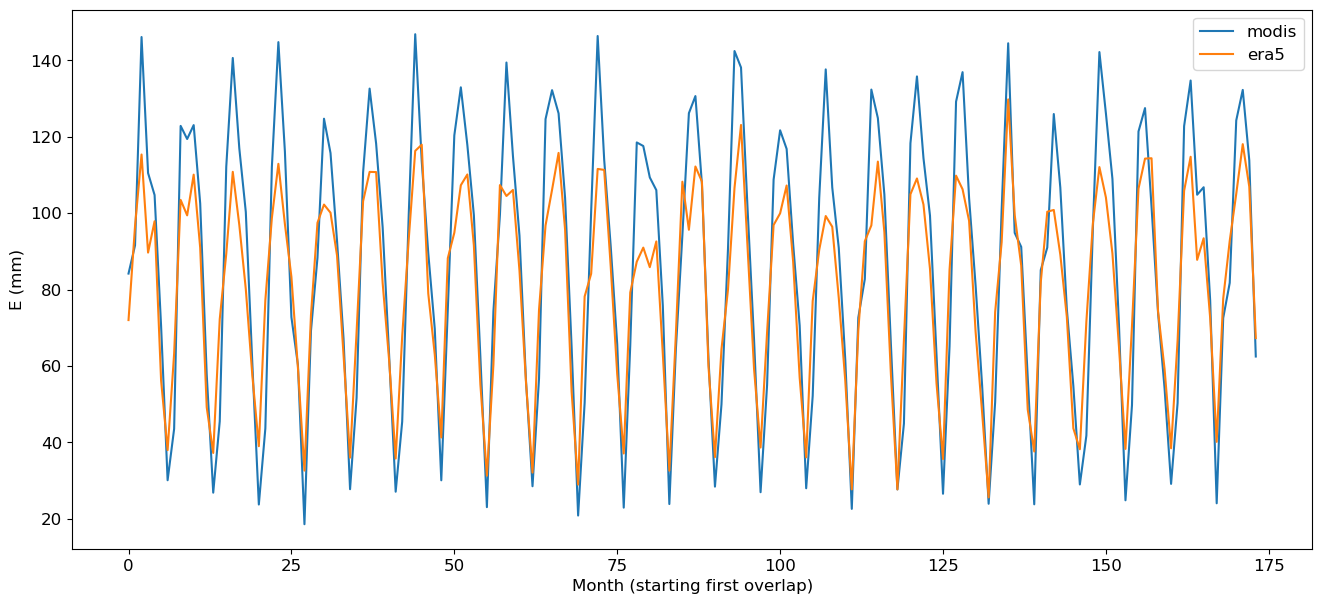

In [20]:
# import evaporation (april to october)
modis = pd.read_csv("Moselle_MODIS_061_MOD16A2GF_ET_1999-06-01_2024-10-01.csv")
modis['datetime'] = pd.to_datetime(modis['system:index'], format='%Y_%m_%d')
modis['daily_ET'] = modis['ET'] / 8
modis = modis[modis['datetime'].dt.month.between(4, 10)]  
modis_daily = modis.set_index('datetime').resample('D')['daily_ET'].bfill()
modis_monthly = modis_daily.resample('ME').sum().reset_index()
modis_monthly.columns = ['datetime', 'monthly_ET']
modis_monthly = modis_monthly[modis_monthly['datetime'].dt.month.between(4, 10)]
modis_monthly['datetime'] = modis_monthly['datetime'].dt.to_period('M').dt.to_timestamp() 

era5_evap = pd.read_csv("Moselle_ECMWF_ERA5_LAND_MONTHLY_AGGR_total_evaporation_sum_1999-06-01_2024-10-01.csv")
era5_evap['datetime'] = pd.to_datetime(era5_evap['system:index'], format='%Y%m')
era5_evap['monthly'] = era5_evap['total_evaporation_sum'] * -1 * 1000
era5_evap = era5_evap[era5_evap['datetime'].dt.month.between(4, 10)]

merged_evap = pd.merge(
    modis_monthly[['datetime', 'monthly_ET']],
    era5_evap[['datetime', 'monthly']],
    on='datetime', how='inner'
)

EObs1_final = merged_evap['monthly_ET'].to_numpy()
EObs2_final = merged_evap['monthly'].to_numpy()

plt.figure(figsize=(16, 7))
plt.plot(EObs1_final, label='modis')
plt.plot(EObs2_final, label='era5')
plt.legend()
plt.xlabel('Month (starting first overlap)')
plt.ylabel('E (mm)')
plt.show()

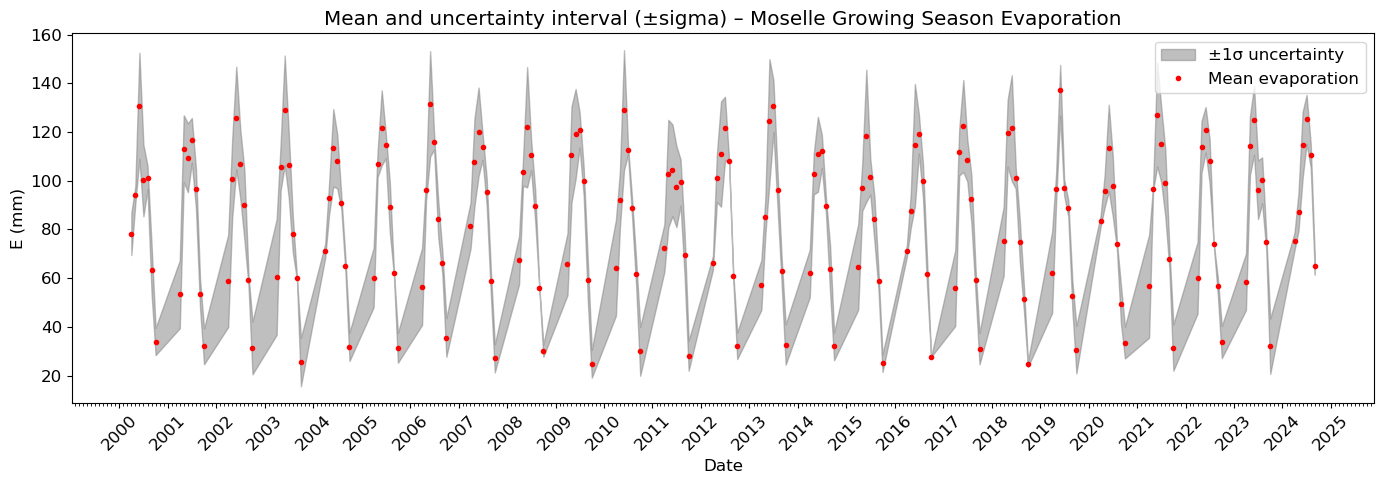

In [21]:
# Plot monthly mean and uncertainty interval (+-sigma) of evaporation
merged_evap['mE'] = (merged_evap['monthly_ET'] + merged_evap['monthly']) / 2
merged_evap['vE'] = (np.square(merged_evap['monthly_ET'] - merged_evap['mE']) +
                     np.square(merged_evap['monthly'] - merged_evap['mE'])) / (2 - 1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(merged_evap['datetime'],
                merged_evap['mE'] - np.sqrt(merged_evap['vE']),
                merged_evap['mE'] + np.sqrt(merged_evap['vE']),
                color='grey', alpha=0.5, label='±1σ uncertainty')
ax.plot(merged_evap['datetime'], merged_evap['mE'], 'r.', label='Mean evaporation')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.set_xlabel('Date')
ax.set_ylabel('E (mm)')
ax.set_title('Mean and uncertainty interval (±sigma) – Moselle Growing Season Evaporation')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# calculate means and perform uncertainty propagation for all 
# refer to Gerrit's notebook


### Classification of plateau/hillslope/wetland

In [38]:
# FlexTOPO, get data and change as needed
DEM = np.genfromtxt('DEM.asc',  dtype=float, autostrip=True, skip_header=6)
slope = np.genfromtxt('slope.asc',  dtype=float, autostrip=True, skip_header=6)
hand = np.genfromtxt('HAND.asc',  dtype=float, autostrip=True, skip_header=6)
basin = np.genfromtxt('basin2.asc',  dtype=float, autostrip=True, skip_header=6) 


In [45]:
DEM_c   = DEM[:3714, :2337]
slope_c = slope[:3714, :2337]
hand_c  = hand[:3714, :2337]
print('DEM:   ', np.array(DEM_c).shape)
print('slope: ', np.array(slope_c).shape)
print('hand:  ', np.array(hand_c).shape)
print('basin: ', np.array(basin).shape)

DEM:   
(3714, 2337)

slope: 
(3714, 2337)

hand:  
(3714, 2337)

basin: 
(3714, 2337)

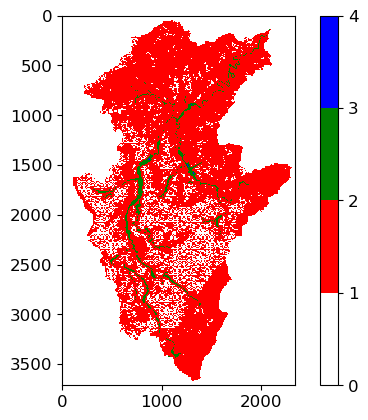

In [48]:
# Make landscape classification
basin_mask = np.array(basin) > 0
nodata = -9999

# Clean nodata values
DEM_c   = np.where(np.array(DEM)   == nodata, np.nan, np.array(DEM))
slope_c = np.where(np.array(slope) == nodata, np.nan, np.array(slope))
hand_c  = np.where(np.array(hand)  == nodata, np.nan, np.array(hand))

DEM_c   = DEM_c[:3714, :2337]
slope_c = slope_c[:3714, :2337]
hand_c  = hand_c[:3714, :2337]

hillslope = (slope_c > 11) & basin_mask
plateau   = (hand_c > 5)  & (slope_c <= 11) & basin_mask
wetland   = (hand_c <= 5) & (slope_c <= 11) & basin_mask

hillslope_per = float(np.sum(hillslope)) / float(np.sum(basin_mask))
wetland_per   = float(np.sum(wetland))   / float(np.sum(basin_mask))
plateau_per   = float(np.sum(plateau))   / float(np.sum(basin_mask))

landscapes = np.zeros(DEM_c.shape)
landscapes[plateau]   = 1
landscapes[hillslope] = 2
landscapes[wetland]   = 3
landscapes = np.where(basin_mask, landscapes, np.nan)

cmap = mpl.colors.ListedColormap(['white', 'red', 'green', 'blue'])
cmap.set_bad(color='white')  # nan cells render as white/transparent
bounds = [0, 1, 2, 3, 4]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

plt.figure(3)
plt.imshow(landscapes, cmap=cmap, norm=norm)
plt.colorbar()
plt.show()

$Su_{max} = Su_{max}0 - \gamma *\Delta T$ 

So in the HBV model, $Su_{max}$ is replaced by two parameters, $Su_{max}0$ and $\gamma$. $\gamma$ is in mm/deg Celcius. 

In [ ]:
# Step 1: Using posterior means, run MC to get parameters


In [ ]:
# step 2: plot modelled Q vs actual Q 




In [ ]:
# step 3: project Q 20 years ahead, using finalized model. 
# import projected temps, precipitation etc


In [ ]:
# results and discussion: Comment on discharge, flood risks etc. 
# We'll be plotting Q or Su_max against temperature 
# when analyzing flood risks, plot Q or "flood risk" against time 

